In [136]:
from matplotlib.pylab import logistic
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import category_encoders as ce
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from scipy.stats import loguniform, randint
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
import wget

In [42]:
wget.download("https://github.com/Moradnejad/AgeDataset/blob/main/AgeDataset-V1-Part1.csv")
baza = pd.read_csv("AgeDataset-V1-Part1.csv")

In [ ]:
mmsc = MinMaxScaler()

koszyki = [-float('inf'), 40, 66, float('inf')]
etykiety = [0, 1, 2]
baza = baza.dropna(subset=["Age of death", "Birth year", "Gender"])

baza = baza[baza['Birth year']>=1900]
baza = baza[baza["Age of death"].between(15, 120)]

baza = baza[baza["Gender"].isin(["Male", "Female"])]
mapping = {'Male': 0, 'Female': 1}
baza["IsFemale"] = baza["Gender"].map(mapping)





baza = baza[(baza["Age of death"] >= 0) & (baza["Age of death"] <= 120)]
baza = baza[baza["Death year"] >= baza["Birth year"]]
#baza = baza.dropna(subset=["Death year"]).reset_index(drop=True)

baza["Occupation_death_mean_age"] = baza.groupby("Occupation")["Age of death"].transform("mean").round(1)
baza["Occupation_death_mean_age_scaled"] = mmsc.fit_transform(baza[["Occupation_death_mean_age"]])
baza = baza.dropna(subset=["Occupation_death_mean_age"])

baza["Death Age Group"]= pd.cut(baza["Age of death"], bins=koszyki, labels=etykiety)
baza["job_safety_level"] = pd.cut(baza["Occupation_death_mean_age"], bins=koszyki, labels=etykiety)



Liczba duplikatów: 0
Id                                  0
Name                                0
Short description                   0
Gender                              0
Country                             0
Occupation                          0
Birth year                          0
Death year                          0
Manner of death                     0
Age of death                        0
IsFemale                            0
Occupation_death_mean_age           0
Occupation_death_mean_age_scaled    0
Death Age Group                     0
job_safety_level                    0
dtype: int64
14788
Index(['Id', 'Name', 'Short description', 'Gender', 'Country', 'Occupation',
       'Birth year', 'Death year', 'Manner of death', 'Age of death',
       'IsFemale', 'Occupation_death_mean_age',
       'Occupation_death_mean_age_scaled', 'Death Age Group',
       'job_safety_level'],
      dtype='str')


In [ ]:
print(f"Liczba duplikatów: {baza.duplicated().sum()}")
print(baza.isnull().sum())
print(baza.shape[0])
print(baza.describe)
print(baza.columns)

Liczba duplikatów: 0
Id                                  0
Name                                0
Short description                   0
Gender                              0
Country                             0
Occupation                          0
Birth year                          0
Death year                          0
Manner of death                     0
Age of death                        0
IsFemale                            0
Occupation_death_mean_age           0
Occupation_death_mean_age_scaled    0
Death Age Group                     0
job_safety_level                    0
dtype: int64
14788
<bound method NDFrame.describe of              Id              Name  \
0           Q42     Douglas Adams   
1          Q303     Elvis Presley   
2          Q368  Augusto Pinochet   
3          Q407    Linda Lovelace   
4          Q409        Bob Marley   
...         ...               ...   
14783  Q2391022      Gordon Solie   
14784  Q2391510    Grigori Shtern   
14785  Q2391576        

In [139]:
def Histogram(column):
    
    column.hist(bins=80, figsize=(20,15))
    plt.show()

def WykresSlupkowyPlec(df):
    male_age = df[df['Gender'] == 'Male']['Age of death'].dropna()
    female_age = df[df['Gender'] == 'Female']['Age of death'].dropna()
    plt.violinplot([male_age, female_age], showmeans=True)
    plt.xticks([1,2], ['Male', 'Female'])
    plt.ylabel('Age of Death')
    plt.title('Distribution of Age of Death')
    plt.show()




def Macierz(columns):
    macierz_korelacji = columns.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        macierz_korelacji,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        fmt = ".2f",
        linewidths=0.5,
    )
    plt.title("Macierz korelacji")
    plt.show()


def DobieranieParametrow(model,y:pd.Series,X:pd.Series):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    sc = MinMaxScaler()

    X_train_std = sc.fit_transform(X_train)
    X_test_std = sc.transform(X_test)

    if(model == "LogisticRegression"):
        model_lr = LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=42
        )

  
        param_dist = {
            "C": loguniform(1e-3, 1e2),
            "solver": ["lbfgs", "saga"],
        }
    elif(model == "DecisionTree"):
        model_lr = DecisionTreeClassifier(random_state=42)

        param_dist = {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_split": randint(2, 11),
            "min_samples_leaf": randint(1,5),
        }
    elif(model =="LinearRegression"):
        model_lr = LinearRegression(
            
        )


    random_search = RandomizedSearchCV(
        estimator=model_lr, 
        param_distributions=param_dist,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
    )

    random_search.fit(X_train_std, y_train)

    print(f"Najlepsze parametry: {random_search.best_params_}")
    print(f"Najlepszy wynik na walidacji: {random_search.best_score_:.2f}")


def RegresjaLogistyczna(y:pd.Series, X:pd.Series,c=0.01,Solver="saga",) -> pd.Series:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    sc = MinMaxScaler()

    X_train_std = sc.fit_transform(X_train)
    X_test_std = sc.transform(X_test)


    re = LogisticRegression(
        C=0.01,
        solver=Solver,
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        
    )


    re.fit(X_train_std, y_train)
    y_pred = re.predict(X_test_std)
    return (y_test, y_pred)






def Przedziały(kat1:pd.Series, kat2:pd.Series, Max_depth=5,Min_samples_leaf=2,Min_samples_split=5) -> list:
    X_tree = kat1
    y_tree = kat2
    drzewo = DecisionTreeClassifier(max_depth=Max_depth,min_samples_leaf=Min_samples_leaf,min_samples_split=Min_samples_split, random_state=42, class_weight='balanced')
    drzewo.fit(X_tree, y_tree)
    wewnetrzne_progi = drzewo.tree_.threshold
    progi = sorted(list(set([round(float(p), 2) for p in wewnetrzne_progi if p != -2])))
    print("Wyciągnięte progi:", progi)
    #new_column = pd.cut(df[kat1], bins=[-1] + progi + [float('inf')], labels=False)
    #print(df[["Age of death", "AgeGroup"]].head(10))
    return progi
    #print(export_text(drzewo, feature_names=["Age of death"]))

    #return (progi)

def Tree_Pred(y:pd.Series, X:pd.Series) -> pd.Series:

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=5, min_samples_leaf=2, class_weight='balanced')
    tree_clf.fit(X_train, y_train)
    y_pred = tree_clf.predict(X_test)
    return (y_test, y_pred)

def Tree_Reg(y:pd.Series, X:pd.Series):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    tree_clf = DecisionTreeRegressor(max_depth=5, random_state=42, min_samples_split=5, min_samples_leaf=2)
    tree_clf.fit(X_train, y_train)
    y_pred = tree_clf.predict(X_test)
    return (y_test, y_pred)


def Walidacja(y_test_pred, test_type="classification"):
    y_test = y_test_pred[0]
    y_pred = y_test_pred[1]
    if test_type == "classification":
        clsrp = classification_report(y_test, y_pred,zero_division=0)
        print(clsrp)
    elif test_type == "regression":
        mse = mean_squared_error(y_test, y_pred)
        print(f"Mean Squared Error: {mse}")


def RegresjaLiniowa(y:pd.Series, X:pd.Series) -> pd.Series:

    y.dropna()
    X.dropna()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    sc = MinMaxScaler()

    X_train_std = sc.fit_transform(X_train)
    X_test_std = sc.transform(X_test)

    lr = LinearRegression()

    lr.fit(X_train_std, y_train)
    y_pred = lr.predict(X_test_std)
    return (y_test, y_pred)

def RandomLas(y:pd.Series,X:pd.Series):
    X_train, X_test, y_train,y_test = train_test_split(
        X,y, test_size=0.3, random_state=42, stratify=y 
    )

    tree_rand = RandomForestClassifier()
    tree_rand.fit(X_train, y_train)
    y_pred = tree_rand.predict(X_test)
    return(y_test, y_pred)

def RandomLasReg(y:pd.Series,X:pd.Series):
    X_train, X_test, y_train,y_test = train_test_split(
        X,y, test_size=0.3, random_state=42, stratify=y 
    )

    tree_rand = RandomForestRegressor()
    tree_rand.fit(X_train, y_train)
    y_pred = tree_rand.predict(X_test)
    return(y_test, y_pred)

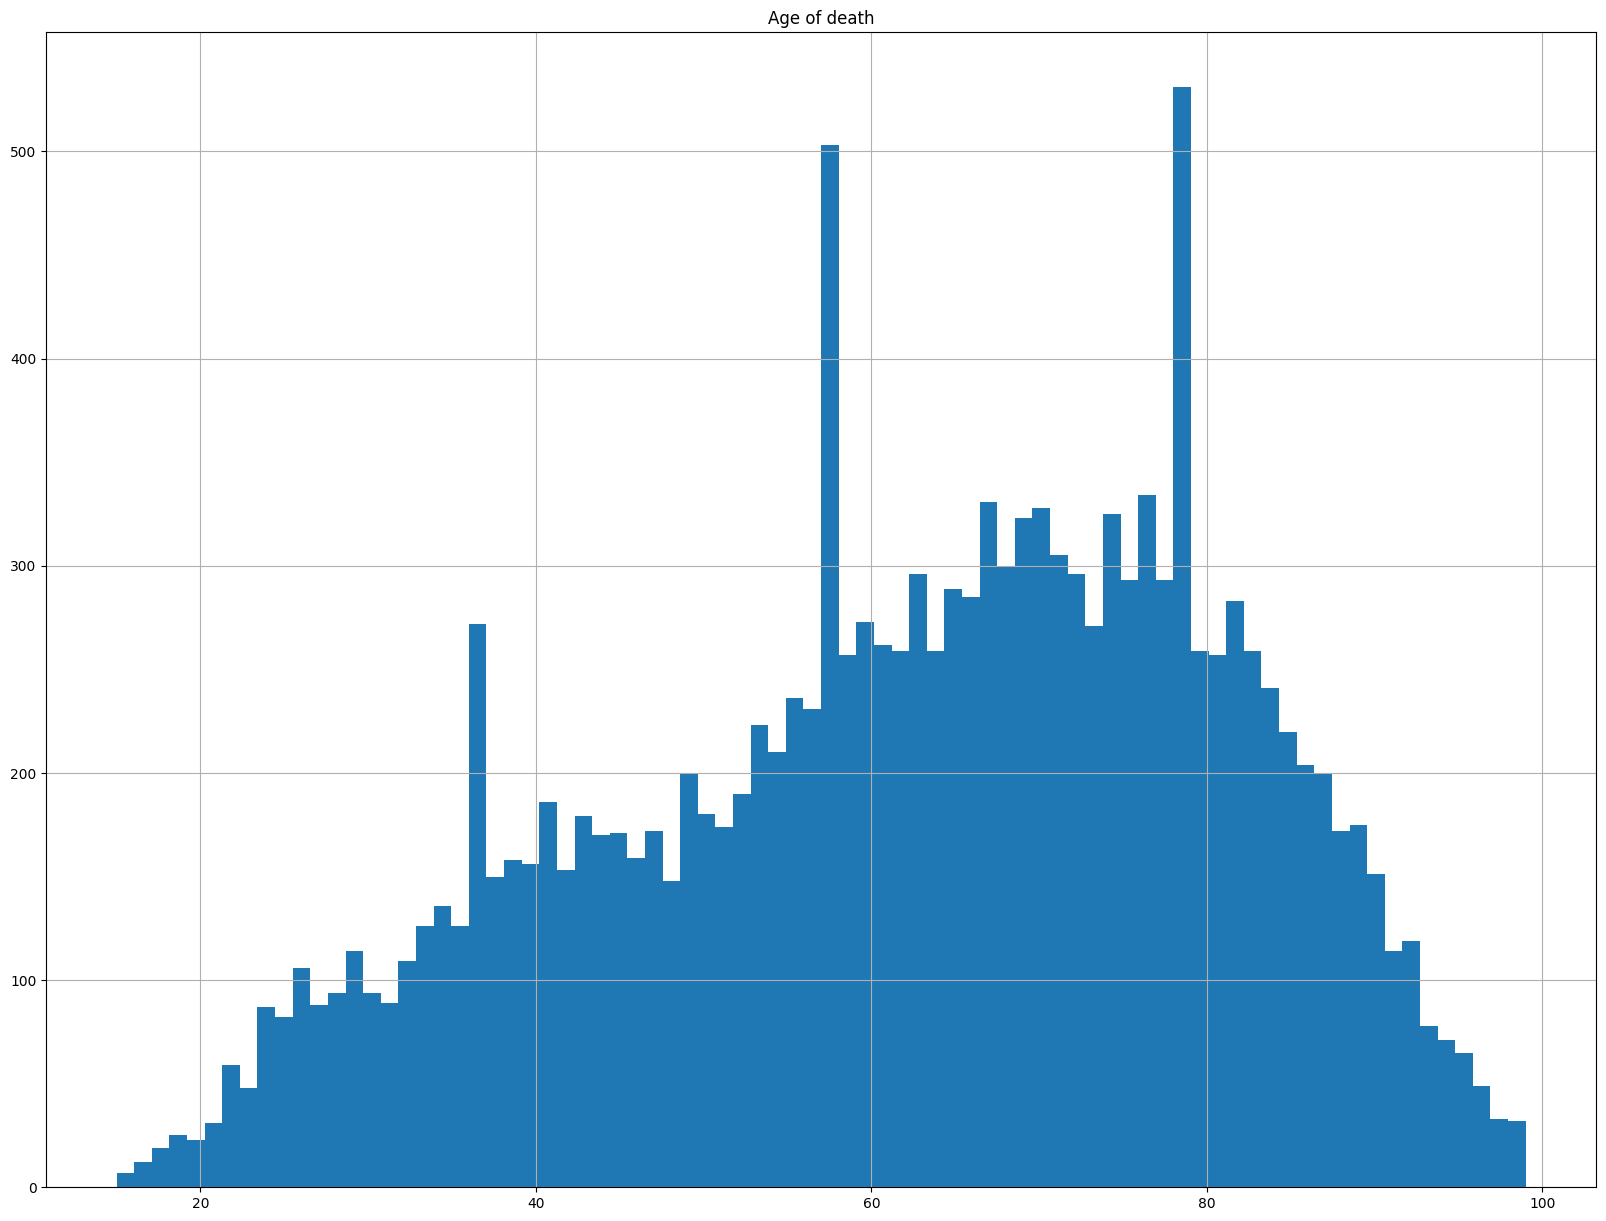

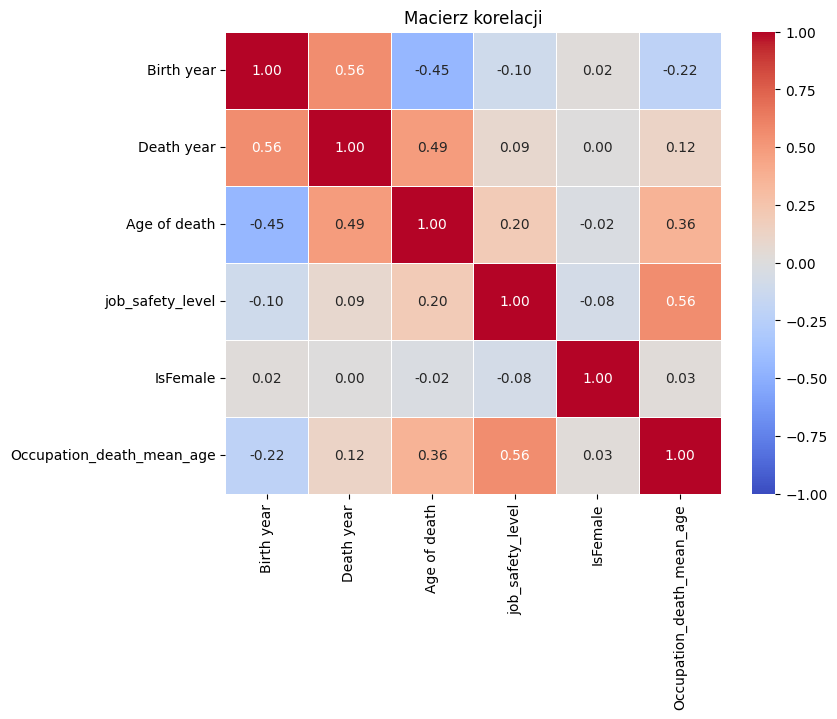

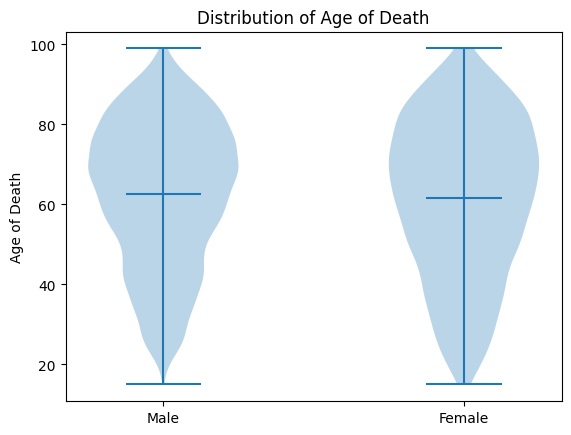

Mean Squared Error: 252.3085906007483
Mean Squared Error: 214.2116321817303
Mean Squared Error: 205.97091471582277
              precision    recall  f1-score   support

           0       0.88      0.09      0.16       663
           1       0.40      0.91      0.55      1700
           2       0.64      0.15      0.25      2074

    accuracy                           0.43      4437
   macro avg       0.64      0.38      0.32      4437
weighted avg       0.58      0.43      0.35      4437



C:\Users\macie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.88      0.09      0.16       663
           1       0.00      0.00      0.00      1700
           2       0.47      1.00      0.64      2074

    accuracy                           0.48      4437
   macro avg       0.45      0.36      0.27      4437
weighted avg       0.35      0.48      0.33      4437



In [ ]:
Histogram(baza[["Age of death"]])
Macierz(baza[['Birth year', 'Death year', 'Age of death', 'job_safety_level',"IsFemale", "Occupation_death_mean_age"]])
WykresSlupkowyPlec(baza)

Walidacja(RegresjaLiniowa(y=baza["Age of death"], X=baza[["Occupation_death_mean_age_scaled", "Birth year"]]),test_type="regression")
Walidacja(RandomLasReg(y=baza["Age of death"], X=baza[["Occupation_death_mean_age_scaled", "Birth year"]]),test_type="regression")
Walidacja(Tree_Reg(y=baza["Age of death"], X=baza[["Occupation_death_mean_age_scaled", "Birth year"]]),test_type="regression")

Walidacja(Tree_Pred(baza["Death Age Group"], baza[["job_safety_level"]]), test_type="classification")
Walidacja(RandomLas(y=baza["Death Age Group"], X=baza[["job_safety_level"]]),test_type="classification")



